In [ ]:
# Copyright 2026 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.



```
# 此内容为代码格式
```

# Gemini 3.1 Flash Image (Nano Banana 2 🍌) Generation on Vertex AI

<table align="left">
  <td style="text-align: center">
    <a href="https://colab.research.google.com/github/GoogleCloudPlatform/generative-ai/blob/main/gemini/getting-started/intro_gemini_3_1_flash_image_gen.ipynb">
      <img width="32px" src="https://www.gstatic.com/pantheon/images/bigquery/welcome_page/colab-logo.svg" alt="Google Colaboratory logo"><br> Open in Colab
    </a>
  </td>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/colab/import/https:%2F%2Fraw.githubusercontent.com%2FGoogleCloudPlatform%2Fgenerative-ai%2Fmain%2Fgemini%2Fgetting-started%2Fintro_gemini_3_1_flash_image_gen.ipynb">
      <img width="32px" src="https://lh3.googleusercontent.com/JmcxdQi-qOpctIvWKgPtrzZdJJK-J3sWE1RsfjZNwshCFgE_9fULcNpuXYTilIR2hjwN" alt="Google Cloud Colab Enterprise logo"><br> Open in Colab Enterprise
    </a>
  </td>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/workbench/deploy-notebook?download_url=https://raw.githubusercontent.com/GoogleCloudPlatform/generative-ai/main/gemini/getting-started/intro_gemini_3_1_flash_image_gen.ipynb">
      <img src="https://www.gstatic.com/images/branding/gcpiconscolors/vertexai/v1/32px.svg" alt="Vertex AI logo"><br> Open in Vertex AI Workbench
    </a>
  </td>
  <td style="text-align: center">
    <a href="https://github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/getting-started/intro_gemini_3_1_flash_image_gen.ipynb">
      <img width="32px" src="https://raw.githubusercontent.com/primer/octicons/refs/heads/main/icons/mark-github-24.svg" alt="GitHub logo"><br> View on GitHub
    </a>
  </td>
</table>

<div style="clear: both;"></div>

<b>Share to:</b>

<a href="https://www.linkedin.com/sharing/share-offsite/?url=https%3A//github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/getting-started/intro_gemini_3_1_flash_image_gen.ipynb" target="_blank">
  <img width="20px" src="https://upload.wikimedia.org/wikipedia/commons/8/81/LinkedIn_icon.svg" alt="LinkedIn logo">
</a>

<a href="https://bsky.app/intent/compose?text=https%3A//github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/getting-started/intro_gemini_3_1_flash_image_gen.ipynb" target="_blank">
  <img width="20px" src="https://upload.wikimedia.org/wikipedia/commons/7/7a/Bluesky_Logo.svg" alt="Bluesky logo">
</a>

<a href="https://twitter.com/intent/tweet?url=https%3A//github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/getting-started/intro_gemini_3_1_flash_image_gen.ipynb" target="_blank">
  <img width="20px" src="https://upload.wikimedia.org/wikipedia/commons/5/5a/X_icon_2.svg" alt="X logo">
</a>

<a href="https://reddit.com/submit?url=https%3A//github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/getting-started/intro_gemini_3_1_flash_image_gen.ipynb" target="_blank">
  <img width="20px" src="https://redditinc.com/hubfs/Reddit%20Inc/Brand/Reddit_Logo.png" alt="Reddit logo">
</a>

<a href="https://www.facebook.com/sharer/sharer.php?u=https%3A//github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/getting-started/intro_gemini_3_1_flash_image_gen.ipynb" target="_blank">
  <img width="20px" src="https://upload.wikimedia.org/wikipedia/commons/5/51/Facebook_f_logo_%282019%29.svg" alt="Facebook logo">
</a>

| Author |
| --- |
| [Katie Nguyen](https://github.com/katiemn) |

## Overview
This notebook will show you how to use the Gemini 3.1 Flash Image (Nano Banana 2) image model. This model is a powerful, generalist multimodal model that offers state-of-the-art image generation and conversational image editing capabilities. It's also able to show its work, allowing you to set the thinking level and see the 'thought process' behind the generated output.

In this tutorial, you'll learn how to use gemini-3.1-flash-image-preview in Vertex AI using the Google Gen AI SDK to try out the following scenarios:

- Image generation:
  - Text-to-image generation
  - Model thoughts
  - Prominent people filter
  - Grounding with web and image search
  - Image sizing
- Image editing:
  - Localization
  - Multi-turn image editing (chat)
  - Editing with reference images

## Get started

### Install Google Gen AI SDK for Python


In [3]:
%pip install --upgrade --quiet google-genai

### Authenticate your notebook environment (Colab only)

If you are running this notebook on Google Colab, run the following cell to authenticate your environment.

In [5]:
import sys

if "google.colab" in sys.modules:
    from google.colab import auth

    auth.authenticate_user()

### Import libraries

In [6]:
from IPython.display import Image, Markdown, display
from google import genai
from google.genai import types

import warnings
warnings.filterwarnings("ignore")

### Set Google Cloud project information and create client

To get started using Vertex AI, you must have an existing Google Cloud project and [enable the Vertex AI API](https://console.cloud.google.com/flows/enableapi?apiid=aiplatform.googleapis.com).

Learn more about [setting up a project and a development environment](https://cloud.google.com/vertex-ai/docs/start/cloud-environment).

In [7]:
import os

PROJECT_ID = "solid-hope-430600-f0"  # @param {type: "string", placeholder: "[your-project-id]", isTemplate: true}
if not PROJECT_ID or PROJECT_ID == "[your-project-id]":
    PROJECT_ID = str(os.environ.get("GOOGLE_CLOUD_PROJECT"))

LOCATION = "global"

client = genai.Client(vertexai=True, project=PROJECT_ID, location=LOCATION)

### Load the model

In [8]:
MODEL_ID="gemini-3.1-flash-image-preview"

## Image generation

### Text-to-image

In the cell below, you'll call the `generate_content` method and modify the following arguments:

  - `prompt`: A text-only user message describing the image to be generated.
  - `config`: A config for specifying content settings.
    - `response_modalities`: To generate an image, you must include `IMAGE` in the `response_modalities` list. To get both text and images, specify `IMAGE` and `TEXT`.
    - `ImageConfig`: Set the `aspect_ratio`. Valid ratios are: 1:1, 3:2, 2:3, 3:4, 4:3, 1:4, 4:1, 4:5, 5:4, 1:8, 8:1, 9:16, 16:9, 21:9
    - `ThinkingConfig`: Set the `thinking_level` to `HIGH` or `MINIMAL`, and if you'd like to view the model thoughts, set `include_thoughts` to `True`.
      - `HIGH`: Allows the model to use more tokens for thinking and is suitable for complex prompts requiring deep reasoning.
      - `MINIMAL`: Constrains the model to use as few tokens as possible for thinking and is best used for low-complexity tasks.


All generated images include a [SynthID watermark](https://deepmind.google/technologies/synthid/), which can be verified via the Media Studio in [Vertex AI Studio](https://cloud.google.com/generative-ai-studio?hl=en).

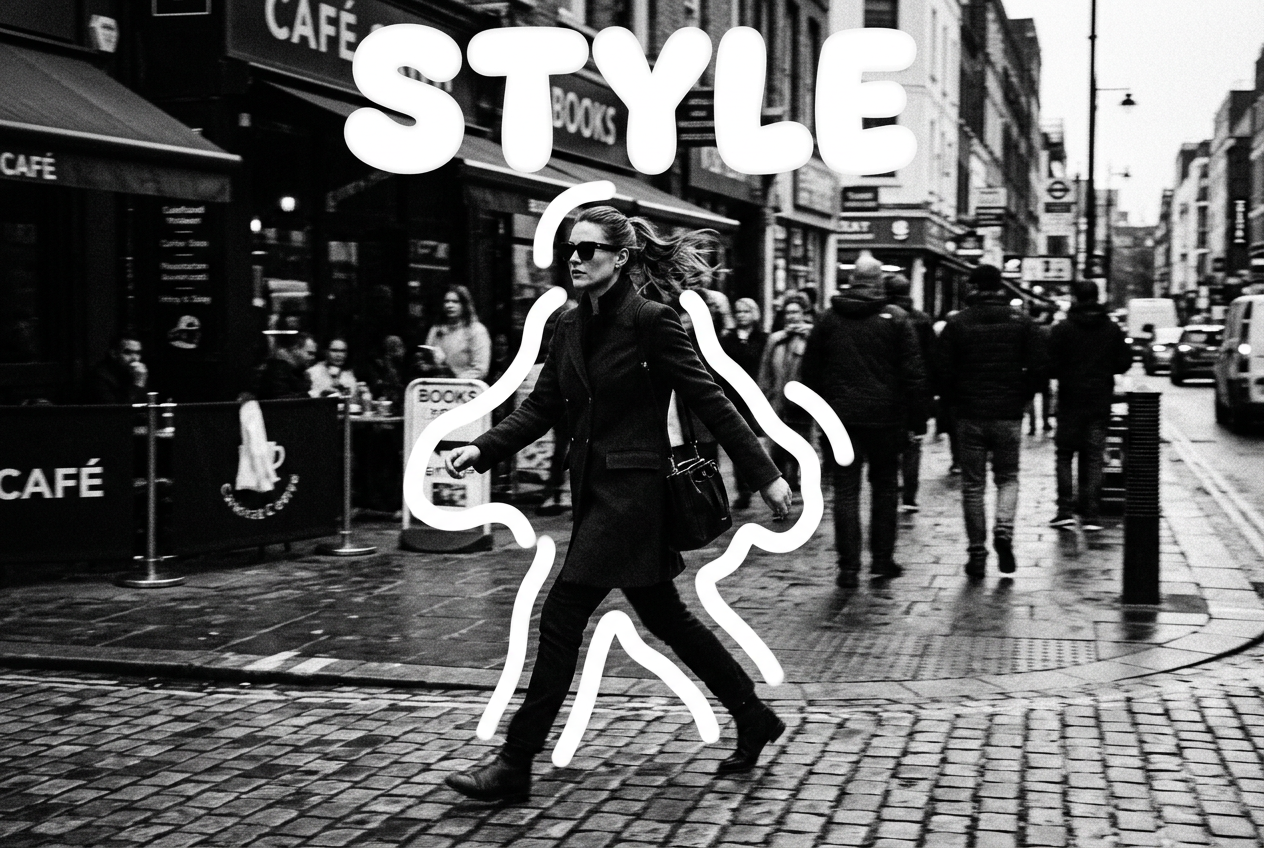

In [11]:
prompt = """
A high-contrast, grainy black and white street photography shot. A woman in dark sunglasses is captured in mid-stride with elegant motion blur. Overlaid on the image are large, white, pillowy bubble lines that curve around her to trace her silhouette. A word is added to the top of the image in the same white, bubble font: STYLE.
"""
aspect_ratio = "3:2"

response = client.models.generate_content(
    model=MODEL_ID,
    contents=prompt,
    config=types.GenerateContentConfig(
        response_modalities=['IMAGE', 'TEXT'],
        image_config=types.ImageConfig(
            aspect_ratio=aspect_ratio,
            output_mime_type="image/png",
        ),
        thinking_config=types.ThinkingConfig(
            include_thoughts=True,
            thinking_level=types.ThinkingLevel.HIGH
        )
    ),

)

# Check for errors if an image is not generated
if response.candidates[0].finish_reason != types.FinishReason.STOP:
    reason = response.candidates[0].finish_reason
    raise ValueError(f"Prompt Content Error: {reason}")

for part in response.candidates[0].content.parts:
    if part.thought:
        continue # Skip displaying thoughts
    if part.inline_data:
        display(Image(data=part.inline_data.data, width=500))

### See the thoughts

Since this is a thinking model, you can check the thoughts that led to the image being produced.

**Creating a Street Scene**

I'm focusing on the black and white street scene, concentrating on strong contrasts and capturing a sense of movement. The initial image will serve as the canvas for the other elements.




**Adding Bubble Art Overlay**

I'm now incorporating a custom bubble art overlay with text onto the grayscale street scene. I'm focusing on integrating it seamlessly, ensuring it complements the existing elements. I intend the bubble art to interact with the woman in the scene.




**Developing Scene Elements**

My current focus is refining the interplay between the woman and the bubble art overlay. I'm working to ensure the text element, "STYLE," integrates smoothly while maintaining the required visual style. I am refining the placement of the bubble lines to accentuate the woman's motion.




**Detailing the Woman and Overlay**

I'm now focusing on the bubble overlay, making sure the lines clearly trace the woman's form. The word "STYLE" is being positioned to complement the scene. The motion blur in the background is being refined to enhance the contrast with the woman's figure and the bubble lines.




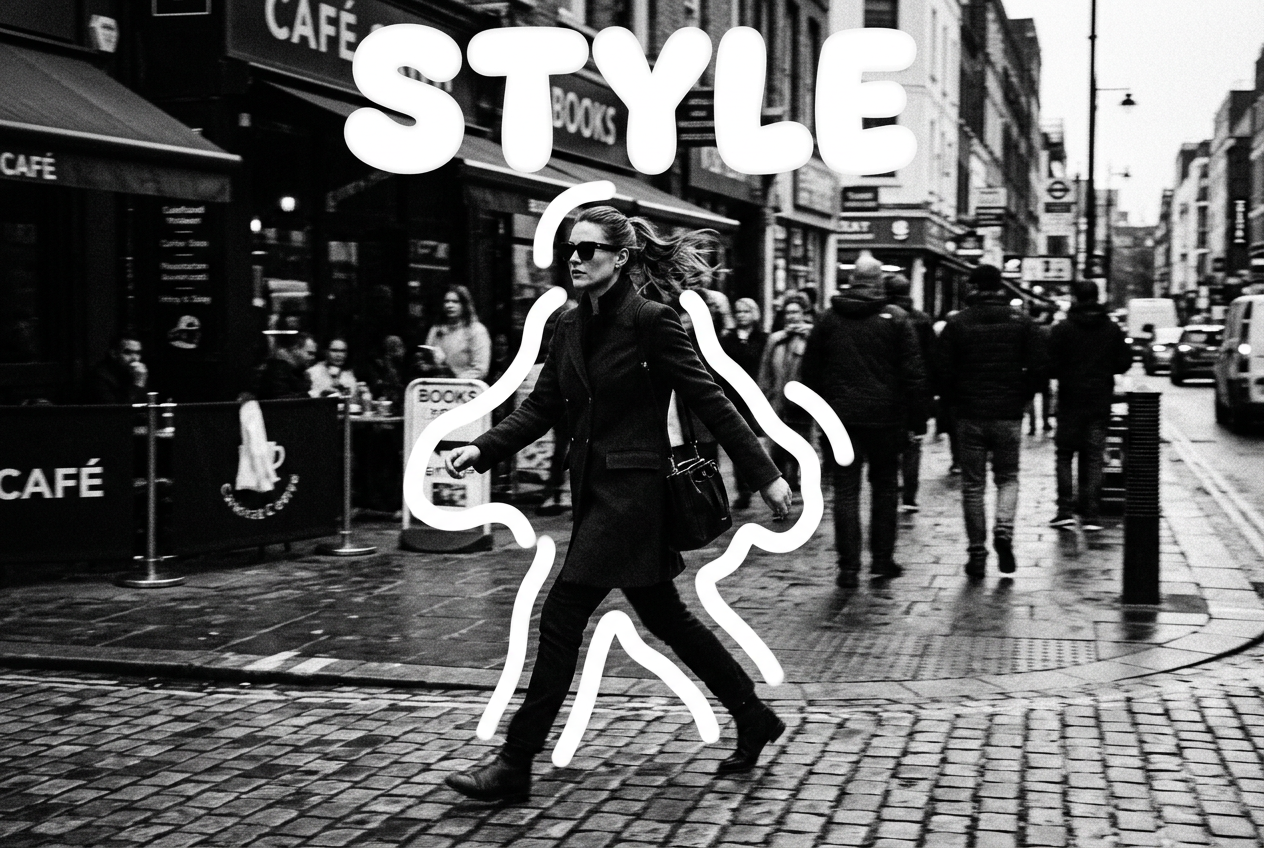

**Analyzing Composition and Style**

I'm currently focused on the prompt's stylistic details and how they're coming across visually. I've noted the mood created by the effects, and I'm ensuring all the elements align with the instructions. The figure's details and positioning also meet my expectations.




**Evaluating Alignment and Details**

I'm checking that the generated image perfectly follows the prompt's instructions. The style, composition, and all visual details match. I'm satisfied that the overlaid text and silhouette are correctly incorporated, and the mood is spot-on. I'm confirming all details are exactly as requested.




In [12]:
for part in response.parts:
  if part.thought:
    if part.text:
      display(Markdown(part.text))
    elif part.inline_data:
      display(Image(data=part.inline_data.data, width=500))

### Prominent people

You can block the model from generating photorealistic images of prominent people by setting `prominent_people` to `types.ProminentPeople.BLOCK_PROMINENT_PEOPLE`.

In [14]:
prompt = "Generate an image of Beyonce"

response = client.models.generate_content(
    model=MODEL_ID,
    contents=prompt,
    config=types.GenerateContentConfig(
        response_modalities=['IMAGE', 'TEXT'],
        image_config=types.ImageConfig(
            aspect_ratio="1:1",
            prominent_people=types.ProminentPeople.BLOCK_PROMINENT_PEOPLE
        ),
    ),

)

# Check for errors if an image is not generated
if response.candidates[0].finish_reason != types.FinishReason.STOP:
    print(response.candidates[0].finish_reason, response.candidates[0].finish_message)
else:
    for part in response.candidates[0].content.parts:
        if part.thought:
            continue
        if part.inline_data:
            display(Image(data=part.inline_data.data, width=500))

FinishReason.IMAGE_SAFETY Unable to show the generated image. Your current ProminentPeople setting filtered the image. You will not be charged for blocked images. Try rephrasing the prompt. If you think this was an error, send feedback. Support code: 15236754.


### Grounding with web search results

With this model, you can also generate responses that are grounded in the results of a Google Search.

To display the grounding data, use the helper function in the following cell.

In [ ]:
def print_search_grounding_data(response: types.GenerateContentResponse) -> None:
    """Prints response with grounding citations in Markdown format."""
    grounding_metadata = response.candidates[0].grounding_metadata
    lines = []

    if response.text:
        ENCODING = "utf-8"
        text_bytes = response.text.encode(ENCODING)
        last_byte_index = 0

        if grounding_metadata.grounding_supports:
            for support in grounding_metadata.grounding_supports:
                lines.append(
                    text_bytes[last_byte_index : support.segment.end_index].decode(ENCODING)
                )
                footnotes = "".join([f"[{i + 1}]" for i in support.grounding_chunk_indices])
                lines.append(f" {footnotes}")
                last_byte_index = support.segment.end_index

        if last_byte_index < len(text_bytes):
            lines.append(text_bytes[last_byte_index:].decode(ENCODING))

    lines.append("\n\n----\n## Grounding Sources\n")

    if grounding_metadata.grounding_chunks:
        lines.append("### Grounding Chunks\n")
        for i, chunk in enumerate(grounding_metadata.grounding_chunks, start=1):
            context = chunk.web or chunk.retrieved_context or chunk.maps
            image = chunk.image

            if not context and not image:
                continue

            if image:
                title = image.title or "Image Source"
                uri = image.source_uri or "#"
                image_uri = image.image_uri
                domain = image.domain

                lines.append(f"{i}. [{title}]({uri})\n")
                if domain:
                    lines.append(f"    - Domain: `{domain}`\n")
                if image_uri:
                    lines.append(f"    <img src='{image_uri}' width='250'>\n\n")

            elif context:
                uri = context.uri
                title = context.title or "Source"
                if uri:
                    uri = uri.replace(" ", "%20")
                    if uri.startswith("gs://"):
                        uri = uri.replace("gs://", "https://storage.googleapis.com/", 1)

                lines.append(f"{i}. [{title}]({uri})\n")
                if hasattr(context, "text") and context.text:
                    lines.append(f"{context.text}\n\n")

    web_queries = grounding_metadata.web_search_queries or []
    image_queries = getattr(grounding_metadata, "image_search_queries", []) or []

    all_queries = list(web_queries) + list(image_queries)

    if all_queries:
        lines.append(f"\n**Web Search Queries:** {all_queries}\n")

        if grounding_metadata.search_entry_point:
            lines.append(
                f"\n**Search Entry Point:**\n{grounding_metadata.search_entry_point.rendered_content}\n"
            )
    elif grounding_metadata.retrieval_queries:
        lines.append(
            f"\n**Retrieval Queries:** {grounding_metadata.retrieval_queries}\n"
        )

    display(Markdown("".join(lines)))

Next, you'll create a Google Search tool and include it in the `tools` parameter of the following request to perform a web search.

In [ ]:
prompt = """
A cinematic, wide-angle illustration of the NFL team's stadium that won the 2026 Super Bowl. Digital art style with high-detail architecture.
"""
google_search = types.Tool(google_search=types.GoogleSearch(
    search_types=types.SearchTypes(
        web_search=types.WebSearch()
    )
))
response = client.models.generate_content(
    model=MODEL_ID,
    contents=prompt,
    config=types.GenerateContentConfig(
        response_modalities=['TEXT', 'IMAGE'],
        image_config=types.ImageConfig(
            aspect_ratio="21:9",
        ),
        thinking_config=types.ThinkingConfig(
            include_thoughts=True,
            thinking_level=types.ThinkingLevel.HIGH
        ),
        tools=[google_search],
    )
)

for part in response.candidates[0].content.parts:
    if part.text:
        display(Markdown(part.text))
    if part.inline_data:
        display(Image(data=part.inline_data.data, width=500))

print_search_grounding_data(response)

Below, you'll do the same thing, except with an image search.

In [ ]:
prompt = "Generate a watercolor image of the Lansdowne Bridge"
google_search = types.Tool(google_search=types.GoogleSearch(
    search_types=types.SearchTypes(
        image_search=types.ImageSearch(),
    )
))

response = client.models.generate_content(
    model=MODEL_ID,
    contents=prompt,
    config=types.GenerateContentConfig(
        response_modalities=['TEXT', 'IMAGE'],
        image_config=types.ImageConfig(
            aspect_ratio="16:9",
        ),
        thinking_config=types.ThinkingConfig(
            include_thoughts=True,
            thinking_level=types.ThinkingLevel.HIGH
        ),
        tools = [google_search],
    )
)

for part in response.candidates[0].content.parts:
    if part.text:
        display(Markdown(part.text))
    if part.inline_data:
        display(Image(data=part.inline_data.data, width=500))


print_search_grounding_data(response)

### Image sizes

You can have Nano Banana 2 generate images with an `image_size` of `512`, `1K`, `2K`, or `4K`.

In [ ]:
prompt = """
Macro photography of a vibrant teal and lime green chameleon perched on a mossy branch.
"""

response = client.models.generate_content(
    model=MODEL_ID,
    contents=prompt,
    config=types.GenerateContentConfig(
        response_modalities=['TEXT', 'IMAGE'],
        image_config=types.ImageConfig(
            aspect_ratio="1:1",
            image_size="4K",
        ),
    )
)

for part in response.candidates[0].content.parts:
    if part.thought:
        continue
    if part.inline_data:
        display(Image(data=part.inline_data.data, width=500))

## Image editing

You can also edit images with this model; simply pass the original image as part of the prompt.

### Localization

You can also translate the text in images through image editing. Start by downloading the image and displaying it below.

In [ ]:
!wget https://storage.googleapis.com/cloud-samples-data/generative-ai/image/city-street.png

starting_image = "city-street.png"
display(Image(filename=starting_image, width=500))

In [ ]:
with open(starting_image, "rb") as f:
    image = f.read()

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        types.Part.from_bytes(
            data=image,
            mime_type="image/png",
        ),
        "Change the text in this infographic from English to Japanese.",
    ],
    config=types.GenerateContentConfig(
        response_modalities=['TEXT', 'IMAGE'],
    ),
)

for part in response.candidates[0].content.parts:
    if part.text:
        display(Markdown(part.text))
    if part.inline_data:
        display(Image(data=part.inline_data.data, width=500))

### Multi-turn image editing (chat)

In this next section, you'll generate a starting image and iteratively alter certain aspects of the image by chatting with the model.

In [ ]:
chat = client.chats.create(
    model=MODEL_ID,
    config=types.GenerateContentConfig(
        response_modalities=['TEXT', 'IMAGE']
    )
)

message = "A minimalist overhead shot of two dense florist buckets on a smooth grey pavement. One contains a bouquet of pink baby's breath, and the other contains a cluster of pale blush poppies."
response = chat.send_message(message)

for part in response.candidates[0].content.parts:
    if part.thought:
        continue
    if part.inline_data:
        display(Image(data=part.inline_data.data, width=500))

Now, you'll send a new message in the existing chat to update the previously generated image.

In [ ]:
message = "Change the poppies to white dahlias and add a third bucket of pink hydrangeas in the top right corner."
response = chat.send_message(message)

for part in response.candidates[0].content.parts:
    if part.thought:
        continue
    if part.inline_data:
        display(Image(data=part.inline_data.data, width=500))

### Multiple reference images

With Nano Banana 2, you can include up to 14 reference images in a request to generate a new image that preserves the content of the original images.

Run the following cell to visualize the starting images stored in Cloud Storage.

In [ ]:
import requests
from PIL import Image as PIL_Image
from io import BytesIO
import matplotlib.pyplot as plt

image_urls = [
    "https://storage.googleapis.com/cloud-samples-data/generative-ai/image/woman.jpeg",
    "https://storage.googleapis.com/cloud-samples-data/generative-ai/image/black-boots.jpg",
    "https://storage.googleapis.com/cloud-samples-data/generative-ai/image/black-bag.jpg",
    "https://storage.googleapis.com/cloud-samples-data/generative-ai/image/shirt.jpg",
    "https://storage.googleapis.com/cloud-samples-data/generative-ai/image/jacket.jpg",
    "https://storage.googleapis.com/cloud-samples-data/generative-ai/image/white-pants.jpg",
]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(PIL_Image.open(BytesIO(requests.get(image_urls[i]).content)))
    ax.axis("off")
plt.show()

The process for sending the request is similar to previous image editing calls. The main difference is that you will provide multiple `Part.from_uri` instances, one for each reference image.

In [ ]:
response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        types.Part.from_uri(
            file_uri="gs://cloud-samples-data/generative-ai/image/woman.jpeg",
            mime_type="image/jpeg",
        ),
        types.Part.from_uri(
            file_uri="gs://cloud-samples-data/generative-ai/image/black-boots.jpg",
            mime_type="image/png",
        ),
        types.Part.from_uri(
            file_uri="gs://cloud-samples-data/generative-ai/image/black-bag.jpg",
            mime_type="image/png",
        ),
        types.Part.from_uri(
            file_uri="gs://cloud-samples-data/generative-ai/image/shirt.jpg",
            mime_type="image/png",
        ),
        types.Part.from_uri(
            file_uri="gs://cloud-samples-data/generative-ai/image/jacket.jpg",
            mime_type="image/jpeg",
        ),
        types.Part.from_uri(
            file_uri="gs://cloud-samples-data/generative-ai/image/white-pants.jpg",
            mime_type="image/png",
        ),
        types.Part.from_uri(
            file_uri="gs://cloud-samples-data/generative-ai/image/white-pants.jpg",
            mime_type="image/png",
        ),
        "Generate an image of a woman wearing white pants, a navy blue shirt, a cropped trench coat, and black boots. She's carrying a black bag. The outline of the woman is cropped against a piece of cardstock with a giant paperclip attached at the top.",
    ],
    config=types.GenerateContentConfig(
        response_modalities=["TEXT", "IMAGE"],
        image_config=types.ImageConfig(
            aspect_ratio="4:3",
        ),
    ),
)

for part in response.candidates[0].content.parts:
    if part.text:
        display(Markdown(part.text))
    if part.inline_data:
        display(Image(data=part.inline_data.data, width=500))